In [3]:
%pip install kagglehub


   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   ------------------------------ --------- 3/4 [kagglehub]
   ---------------------------------------- 4/4 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\arockia ludson\.cache\kagglehub\datasets\tongpython\cat-and-dog\versions\1


In [11]:
import os

print(os.listdir(path))

['test_set', 'training_set']


In [14]:
print(os.listdir(os.path.join(path)))

['test_set', 'training_set']


In [21]:
import os
import tensorflow as tf

train_dir = os.path.join(path, "training_set", "training_set")
test_dir = os.path.join(path, "test_set", "test_set")

image_size = (180, 180)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    image_size=image_size,
    batch_size=batch_size,
)

class_names = train_ds.class_names
autotune = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(autotune)
validation_ds = validation_ds.cache().prefetch(autotune)
test_ds = test_ds.cache().prefetch(autotune)

print("Classes:", class_names)
print("Pipeline ready: train, validation, and test datasets created.")

Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.
Found 2023 files belonging to 2 classes.
Classes: ['cats', 'dogs']
Pipeline ready: train, validation, and test datasets created.


In [22]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [23]:
tf.keras.layers.Rescaling(1./255)

<Rescaling name=rescaling, built=False>

In [25]:
# Build, compile, and train the cat-vs-dog classifier
model = tf.keras.Sequential([
    tf.keras.Input(shape=image_size + (3,)),
    data_augmentation,
    tf.keras.layers.Rescaling(1.0 / 255),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_cat_dog_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=callbacks,
)


Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 55s 259ms/step - accuracy: 0.5192 - loss: 0.6990 - val_accuracy: 0.5109 - val_loss: 0.6900
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 52s 259ms/step - accuracy: 0.5815 - loss: 0.6760 - val_accuracy: 0.5278 - val_loss: 0.7225
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 51s 254ms/step - accuracy: 0.6188 - loss: 0.6495 - val_accuracy: 0.6315 - val_loss: 0.6455
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 51s 252ms/step - accuracy: 0.6268 - loss: 0.6458 - val_accuracy: 0.6477 - val_loss: 0.6308
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 50s 250ms/step - accuracy: 0.6537 - loss: 0.6215 - val_accuracy: 0.6421 - val_loss: 0.6312
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 51s 254ms/step - accuracy: 0.6832 - loss: 0.5898 - val_accuracy: 0.6846 - val_loss: 0.5994
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 51s 255ms/step - accuracy: 0.7042 - loss: 0.5670 - val_accuracy: 0.7233 - val_loss: 0.5457
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 51s 254ms/step - accuracy: 0.7264 - loss: 0

Image: C:\Users\arockia ludson\.cache\kagglehub\datasets\tongpython\cat-and-dog\versions\1\test_set\test_set\cats\cat.4001.jpg
Prediction: dogs
Confidence: 90.98%


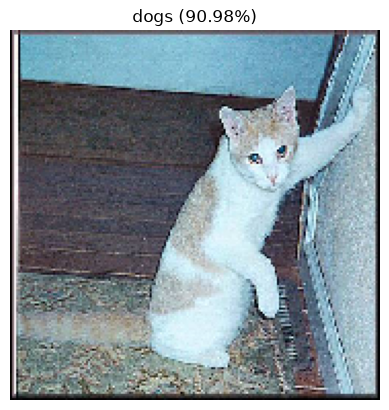

In [27]:
# Predict whether one image is a cat or a dog
import glob
import matplotlib.pyplot as plt

image_path = glob.glob(os.path.join(test_dir, "*", "*"))[0]

image = tf.keras.utils.load_img(image_path, target_size=image_size)
image_array = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_array, axis=0)

predictions = model.predict(image_batch, verbose=0)
predicted_index = int(tf.argmax(predictions[0]))
predicted_class = class_names[predicted_index]
confidence = float(predictions[0][predicted_index]) * 100

print(f"Image: {image_path}")
print(f"Prediction: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

plt.imshow(image)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()